# Automotive Part Image–Text Matching SAT

## Unified Dataset V3 multimodal report

This is the only official project notebook. It consolidates the verified Dataset V3 experiment, its preserved validation and one-time locked final-test results, and a later controlled validation-only auxiliary-loss ablation. It does **not** retrain the original selected model or rerun final-test inference.

## 1. Problem statement

The task is to classify the relation between an automotive-part image and a text description as `MATCH`, `MISMATCH`, or `PARTIAL_MATCH`. Incorrect image-description pairs are relevant to catalogue quality and warehouse picking, while partial matches test whether the model can distinguish related parts from exact matches.

### Hypotheses

- **H1:** the complete multimodal training design will outperform tested unimodal and simple combined baselines.
- **H2:** `PARTIAL_MATCH` will be the most difficult class.
- **H3:** performance will vary across part categories.
- **H4, controlled follow-up:** removing the auxiliary image-category and text-category objectives will reduce validation performance under the same setup.

H1–H3 belong to the original Dataset V3 study. H4 is a retrospective validation-only follow-up and did not influence the frozen final-test result.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

from src.data import PROJECT_ROOT, load_image_manifest, validate_development_dataset
from src.models import (
    ImageRelationCNN,
    MultimodalRelationCNN,
    MultimodalRelationCNNNoAuxiliary,
    TextRelationMLP,
    count_trainable_parameters,
)

RESULTS = PROJECT_ROOT / "results"
manifest = load_image_manifest()
validation_comparison = pd.read_csv(RESULTS / "validation" / "model_comparison.csv")
validation_predictions = pd.read_csv(RESULTS / "validation" / "selected_model_predictions.csv")
validation_metrics = json.loads((RESULTS / "validation" / "selected_model_metrics.json").read_text())
ablation_comparison = pd.read_csv(RESULTS / "ablation" / "auxiliary_loss_ablation_comparison.csv")
ablation_summary = json.loads((RESULTS / "ablation" / "auxiliary_loss_ablation_summary.json").read_text())
test_metrics = json.loads((RESULTS / "final_test" / "test_metrics.json").read_text())
test_predictions = pd.read_csv(RESULTS / "final_test" / "test_predictions.csv")
test_per_category = pd.read_csv(RESULTS / "final_test" / "test_per_category.csv")

print("Project root:", PROJECT_ROOT)
print("Dataset images:", len(manifest))
print("Official model:", validation_metrics["model_slug"])

Project root: /mnt/data/unified_build/output/automotive-part-image-text-matching-sat
Dataset images: 640
Official model: torch_multimodal_dataset_v3


## 2. Dataset V3 and split design

Dataset V3 uses eight automotive-part categories. The project-defined grouped split is independent of the upstream dataset's original split labels. Every image has six relation rows: two for each target class. Image identity, group, path, SHA-256 hash, and exact description text are disjoint across splits.

In [2]:
development_audit = validate_development_dataset(verify_hashes=False)
split_table = (
    manifest.groupby(["split", "part_category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
display(split_table)
print(json.dumps(development_audit, indent=2))

part_category,alternator,brake_disc,brake_pad,coil_spring,headlight,oil_filter,starter,taillight
split,,,,,,,,
test,10,10,10,10,10,10,10,10
train,60,60,60,60,60,60,60,60
validation,10,10,10,10,10,10,10,10


{
  "status": "PASS_DEVELOPMENT_DATASET",
  "images": 640,
  "unique_hashes": 640,
  "split_images": {
    "train": 480,
    "validation": 80,
    "test": 80
  },
  "development_relation_rows": {
    "train": 2880,
    "validation": 480
  },
  "categories": 8,
  "overlap": {
    "train_validation_image_id": 0,
    "train_validation_image_group_id": 0,
    "train_validation_image_path": 0,
    "train_validation_sha256": 0,
    "train_test_image_id": 0,
    "train_test_image_group_id": 0,
    "train_test_image_path": 0,
    "train_test_sha256": 0,
    "validation_test_image_id": 0,
    "validation_test_image_group_id": 0,
    "validation_test_image_path": 0,
    "validation_test_sha256": 0,
    "train_validation_description": 0
  },
  "hashes_verified": false,
  "locked_test_relations_read": false
}


The split contains 480 train images, 80 validation images, and 80 physically separated final-test images. The active development audit checks train and validation relation semantics without opening the locked final-test relation table.

## 3. Models and training objective

Images are resized to 48 × 48 RGB. Text is represented by TF-IDF unigrams and bigrams fitted on train descriptions. The selected model combines a CNN image encoder with an MLP text encoder. Two helper heads predict image and text categories during training.

The complete loss is the relation loss plus `0.40` times each category loss.

In [3]:
parameter_table = pd.DataFrame([
    {"model": "Text MLP", "trainable_parameters": count_trainable_parameters(TextRelationMLP(342))},
    {"model": "Image CNN", "trainable_parameters": count_trainable_parameters(ImageRelationCNN())},
    {"model": "Multimodal with auxiliary objectives", "trainable_parameters": count_trainable_parameters(MultimodalRelationCNN(342))},
    {"model": "Multimodal without auxiliary objectives", "trainable_parameters": count_trainable_parameters(MultimodalRelationCNNNoAuxiliary(342))},
])
display(parameter_table)

,model,trainable_parameters
0,Text MLP,24131
1,Image CNN,21459
2,Multimodal with auxiliary objectives,58579
3,Multimodal without auxiliary objectives,57923


## 4. Original validation comparison

Seven models were compared on validation. Selection was based on development evidence only; the final test was not available during comparison or checkpoint selection.

,model,modality,validation_accuracy,validation_macro_f1,correct_predictions,total_predictions
0,PyTorch multimodal CNN (Dataset V3),image + text,0.785417,0.787284,377,480
1,PyTorch neural text model,text,0.333333,0.292270,160,480
2,PyTorch CNN image model,image,0.333333,0.266627,160,480
3,Image + text Logistic Regression,image + text,0.333333,0.166667,160,480
4,Image pixels + Logistic Regression,image,0.333333,0.166667,160,480
5,Majority baseline,none,0.333333,0.166667,160,480
6,TF-IDF + Logistic Regression,text,0.333333,0.166667,160,480


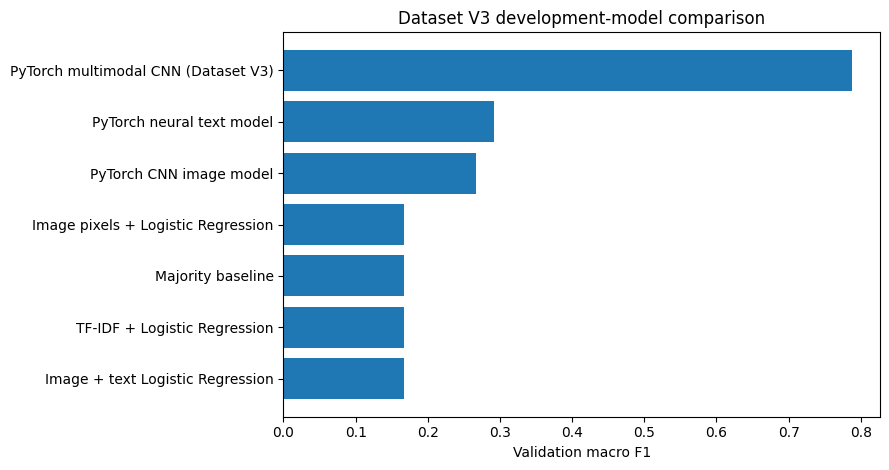

In [4]:
display(validation_comparison[[
    "model", "modality", "validation_accuracy", "validation_macro_f1",
    "correct_predictions", "total_predictions"
]])

plot_data = validation_comparison.sort_values("validation_macro_f1")
plt.figure(figsize=(9, 4.8))
plt.barh(plot_data["model"], plot_data["validation_macro_f1"])
plt.xlabel("Validation macro F1")
plt.title("Dataset V3 development-model comparison")
plt.tight_layout()
plt.show()

In [5]:
val_accuracy = accuracy_score(validation_predictions["true_label"], validation_predictions["predicted_label"])
val_macro_f1 = f1_score(
    validation_predictions["true_label"],
    validation_predictions["predicted_label"],
    average="macro",
    zero_division=0,
)
print(f"Selected validation result: {int(validation_predictions['is_correct'].sum())}/480")
print(f"Accuracy: {val_accuracy:.7f}")
print(f"Macro F1: {val_macro_f1:.7f}")

Selected validation result: 377/480
Accuracy: 0.7854167
Macro F1: 0.7872843


The selected model achieved **377/480**, validation accuracy **0.7854**, and macro F1 **0.7873**. This supports H1 for the *complete* selected training design, not for feature fusion in isolation.

## 5. Controlled auxiliary-loss ablation

The relation-only follow-up removes the image-category head, text-category head, and both auxiliary losses. The shared encoders, relation head, data, optimizer, learning rate, weight decay, batch size, augmentation, and early-stopping rule remain fixed. Seeds `43`, `44`, and `45` use validation only.

,run,auxiliary_category_losses,trainable_parameters,correct_predictions,total_predictions,validation_accuracy,validation_macro_f1,predicted_class_distribution
0,selected model,True,58579,377,480,0.785417,0.787284,saved canonical predictions
1,"no auxiliary, seed 43",False,57923,160,480,0.333333,0.166667,"{""MATCH"": 480, ""MISMATCH"": 0, ""PARTIAL_MATCH"": 0}"
2,"no auxiliary, seed 44",False,57923,160,480,0.333333,0.166667,"{""MATCH"": 0, ""MISMATCH"": 480, ""PARTIAL_MATCH"": 0}"
3,"no auxiliary, seed 45",False,57923,160,480,0.333333,0.166667,"{""MATCH"": 0, ""MISMATCH"": 480, ""PARTIAL_MATCH"": 0}"


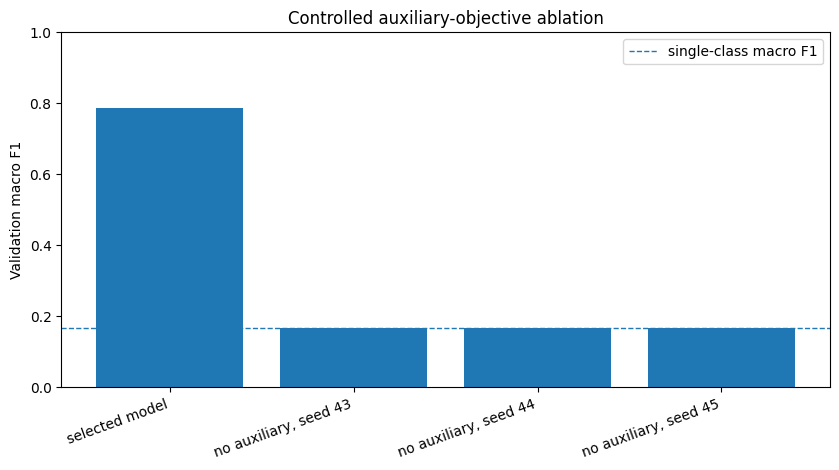

In [6]:
ablation_view = ablation_comparison.copy()
ablation_view["run"] = [
    "selected model" if row.experiment == "selected_multimodal_model"
    else f"no auxiliary, seed {int(row.seed)}"
    for row in ablation_view.itertuples()
]
display(ablation_view[[
    "run", "auxiliary_category_losses", "trainable_parameters",
    "correct_predictions", "total_predictions", "validation_accuracy",
    "validation_macro_f1", "predicted_class_distribution"
]])

plt.figure(figsize=(8.5, 4.8))
plt.bar(ablation_view["run"], ablation_view["validation_macro_f1"])
plt.axhline(1/6, linestyle="--", linewidth=1, label="single-class macro F1")
plt.ylim(0, 1)
plt.ylabel("Validation macro F1")
plt.title("Controlled auxiliary-objective ablation")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
print("Seeds:", ablation_summary["no_auxiliary_aggregate"]["seeds"])
print("Mean no-auxiliary accuracy:", ablation_summary["no_auxiliary_aggregate"]["mean_validation_accuracy"])
print("Mean no-auxiliary macro F1:", ablation_summary["no_auxiliary_aggregate"]["mean_validation_macro_f1"])
print("Accuracy gap:", ablation_summary["validation_accuracy_gap"])
print("Macro-F1 gap:", ablation_summary["validation_macro_f1_gap"])
print("Classes by seed:", ablation_summary["no_auxiliary_aggregate"]["predicted_class_by_seed"])
print("Seed-44 shared initialization:", ablation_summary["seed_44_shared_initialization"])

Seeds: [43, 44, 45]
Mean no-auxiliary accuracy: 0.3333333333333333
Mean no-auxiliary macro F1: 0.16666666666666666
Accuracy gap: 0.45208333333333334
Macro-F1 gap: 0.6206176526591394
Classes by seed: {'43': 'MATCH', '44': 'MISMATCH', '45': 'MISMATCH'}
Seed-44 shared initialization: {'shared_parameter_tensors': 18, 'with_auxiliary_vs_without_auxiliary_equal': True, 'saved_no_auxiliary_initial_state_equal': True}


All three relation-only runs produced **160/480**, accuracy **0.3333**, and macro F1 **0.1667**, collapsing to one class. Seed 43 predicted only `MATCH`; seeds 44 and 45 predicted only `MISMATCH`.

The mean accuracy gap is **0.4521** and the macro-F1 gap is **0.6206**. H4 is supported under this fixed protocol. The result does not imply that all multimodal architectures require auxiliary supervision.

## 6. Frozen final-test result

The selected checkpoint and development notebook were frozen before final-test access. One explicit authorization permitted one evaluation. The authorization is consumed. The cells below read saved final-test result artifacts for reporting and consistency checks; they do not run inference.

In [8]:
test_accuracy = accuracy_score(test_predictions["true_label"], test_predictions["predicted_label"])
test_macro_f1 = f1_score(
    test_predictions["true_label"],
    test_predictions["predicted_label"],
    average="macro",
    zero_division=0,
)
print(f"Frozen final-test result: {int(test_predictions['is_correct'].sum())}/480")
print(f"Accuracy: {test_accuracy:.7f}")
print(f"Macro F1: {test_macro_f1:.10f}")
print("Authorization consumed:", test_metrics["authorization_consumed"])
print("Further tuning permitted:", test_metrics["further_tuning_permitted"])

Frozen final-test result: 354/480
Accuracy: 0.7375000
Macro F1: 0.7382299830
Authorization consumed: True
Further tuning permitted: False


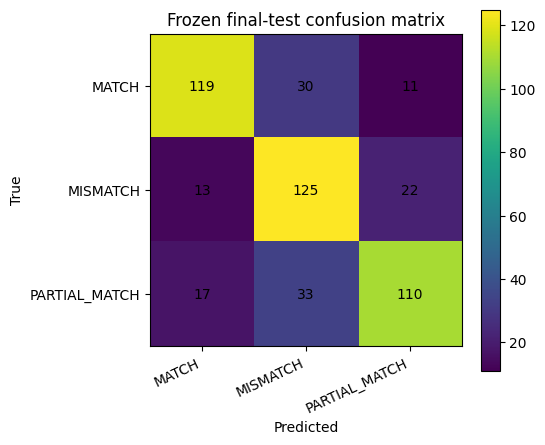

In [9]:
matrix = confusion_matrix(
    test_predictions["true_label"],
    test_predictions["predicted_label"],
    labels=["MATCH", "MISMATCH", "PARTIAL_MATCH"],
)
fig, ax = plt.subplots(figsize=(5.6, 4.8))
image = ax.imshow(matrix)
ax.set_xticks(range(3), ["MATCH", "MISMATCH", "PARTIAL_MATCH"], rotation=25, ha="right")
ax.set_yticks(range(3), ["MATCH", "MISMATCH", "PARTIAL_MATCH"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Frozen final-test confusion matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(matrix[i, j]), ha="center", va="center")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

The frozen checkpoint achieved **354/480**, accuracy **0.7375**, and macro F1 **0.7382**. `PARTIAL_MATCH` has the weakest test recall, supporting H2.

## 7. Category performance and errors

,part_category,samples,independent_images,correct,accuracy,macro_f1
2,brake_pad,60,10,58,0.966667,0.966583
0,alternator,60,10,57,0.950000,0.950653
7,taillight,60,10,53,0.883333,0.884370
3,coil_spring,60,10,49,0.816667,0.820842
1,brake_disc,60,10,43,0.716667,0.716234
6,starter,60,10,35,0.583333,0.582694
5,oil_filter,60,10,30,0.500000,0.504202
4,headlight,60,10,29,0.483333,0.487733


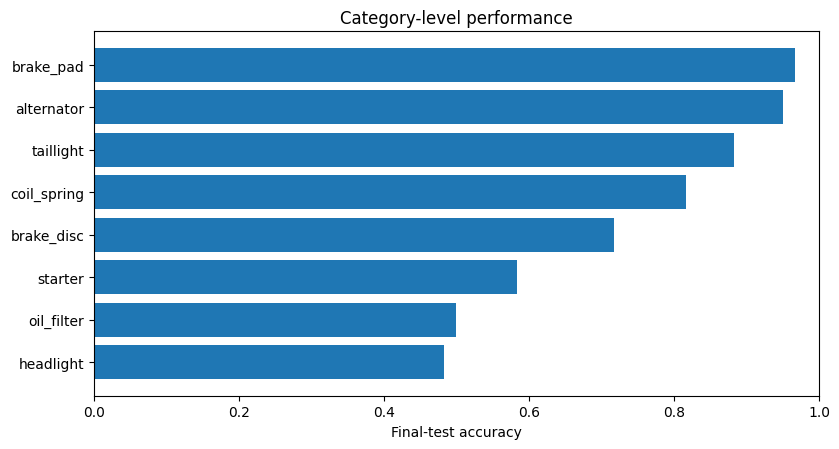

In [10]:
display(test_per_category.sort_values("accuracy", ascending=False))
plt.figure(figsize=(8.5, 4.6))
category_plot = test_per_category.sort_values("accuracy")
plt.barh(category_plot["part_category"], category_plot["accuracy"])
plt.xlim(0, 1)
plt.xlabel("Final-test accuracy")
plt.title("Category-level performance")
plt.tight_layout()
plt.show()

In [11]:
errors = test_predictions.loc[~test_predictions["is_correct"], [
    "part_category", "text_category", "description", "true_label", "predicted_label"
]].head(12)
display(errors)

,part_category,text_category,description,true_label,predicted_label
37,alternator,starter,A automotive starter motor from the engine-sup...,PARTIAL_MATCH,MATCH
40,alternator,starter,This vehicle part is a automotive starter moto...,PARTIAL_MATCH,MATCH
41,alternator,brake_disc,"This vehicle part is a brake disc or rotor, re...",MISMATCH,MATCH
66,brake_disc,brake_disc,"This vehicle part is a brake disc or rotor, re...",MATCH,MISMATCH
67,brake_disc,brake_pad,"This vehicle part is a automotive brake pad, r...",PARTIAL_MATCH,MISMATCH
68,brake_disc,starter,This vehicle part is a automotive starter moto...,MISMATCH,MATCH
69,brake_disc,brake_disc,A brake disc or rotor from the vehicle chassis...,MATCH,MISMATCH
70,brake_disc,brake_pad,A automotive brake pad from the vehicle chassi...,PARTIAL_MATCH,MISMATCH
71,brake_disc,starter,A automotive starter motor from the engine-sup...,MISMATCH,MATCH
73,brake_disc,brake_pad,A automotive brake pad from the vehicle chassi...,PARTIAL_MATCH,MATCH


The visible category differences support H3. Errors show that related functional categories remain difficult, especially where partial matches resemble full mismatches.

## 8. Integrity and reproducibility

In [12]:
assert len(manifest) == 640
assert manifest["sha256"].nunique() == 640
assert int(validation_predictions["is_correct"].sum()) == 377
assert np.isclose(val_accuracy, 0.7854166666666667)
assert np.isclose(val_macro_f1, 0.787284319325806)
assert int(test_predictions["is_correct"].sum()) == 354
assert np.isclose(test_accuracy, 0.7375)
assert np.isclose(test_macro_f1, 0.7382299830250852)
assert ablation_summary["no_auxiliary_aggregate"]["seeds"] == [43, 44, 45]
assert ablation_summary["no_auxiliary_aggregate"]["all_runs_collapsed_to_one_predicted_class"] is True
assert ablation_summary["test_split_used"] is False
print("Notebook integrity checks: PASS")

Notebook integrity checks: PASS


For a complete independent check, run:

```powershell
python -m src.verify --full-hashes
python -m pytest -q
```

The active evaluator supports validation only. The preserved final-test result is verified from saved predictions rather than recreated through another inference run.

## 9. Limitations

- Images come from one public source collection.
- The network is compact and trained from scratch.
- Six rows share every image, so relation rows are not independent.
- The auxiliary-loss conclusion is architecture- and protocol-specific.
- The project is educational and not ready for autonomous warehouse use.
- The ablation is a later explanatory follow-up, not a preregistered part of the original final-test experiment.

## 10. Conclusion

The complete compact multimodal training design clearly outperformed the tested baselines. Its preserved final-test result is 354/480, accuracy 0.7375, and macro F1 0.7382.

The controlled three-seed follow-up clarifies that the gain cannot be attributed to image-text fusion alone: removing auxiliary category supervision caused every relation-only run to collapse to one class. The final interpretation is therefore narrower and more honest: **multimodal fusion with auxiliary category supervision** was successful under this Dataset V3 setup.